In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import prince

from importlib.metadata import version
from pathlib import Path
from matplotlib.transforms import offset_copy

import io
import contextlib
from adjustText import adjust_text

In [2]:
%run LittRuP__import_functions.ipynb

In [3]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()

if BASE_DIR.name == "Notebooks":
    BASE_DIR = BASE_DIR.parent

DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"
DOC_DIR = BASE_DIR / "Docs"

In [4]:

print(f"prince: {version('prince')}")


prince: 0.17.0


In [5]:
# import matrice profil thématique réduit des auteurs

matrix_reduced_profile = pd.read_csv(DAT_DIR / "LittRu_AC_matrix_reduced_profile.csv", sep=',', header=0)

In [6]:
# auteurs en index

matrix_reduced_profile = matrix_reduced_profile.set_index("Author")

**Analyse des correspondances - mise en place**

In [7]:
# sécurité : supprimer lignes ou colonnes nulles éventuelles
X_CA = matrix_reduced_profile.copy()

X_CA = X_CA.loc[
    X_CA.sum(axis=1) > 0,
    X_CA.sum(axis=0) > 0
]

# AC
ca = prince.CA(
    n_components=2,
    n_iter=10,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=0
)

ca = ca.fit(X_CA)

# coordonnées des auteurs et des thèmes
row_coords = ca.row_coordinates(X_CA)
col_coords = ca.column_coordinates(X_CA)

# pourcentages d'inertie expliquée par les axes
pct = ca.percentage_of_variance_

**Analyse des correspondances - graphique**

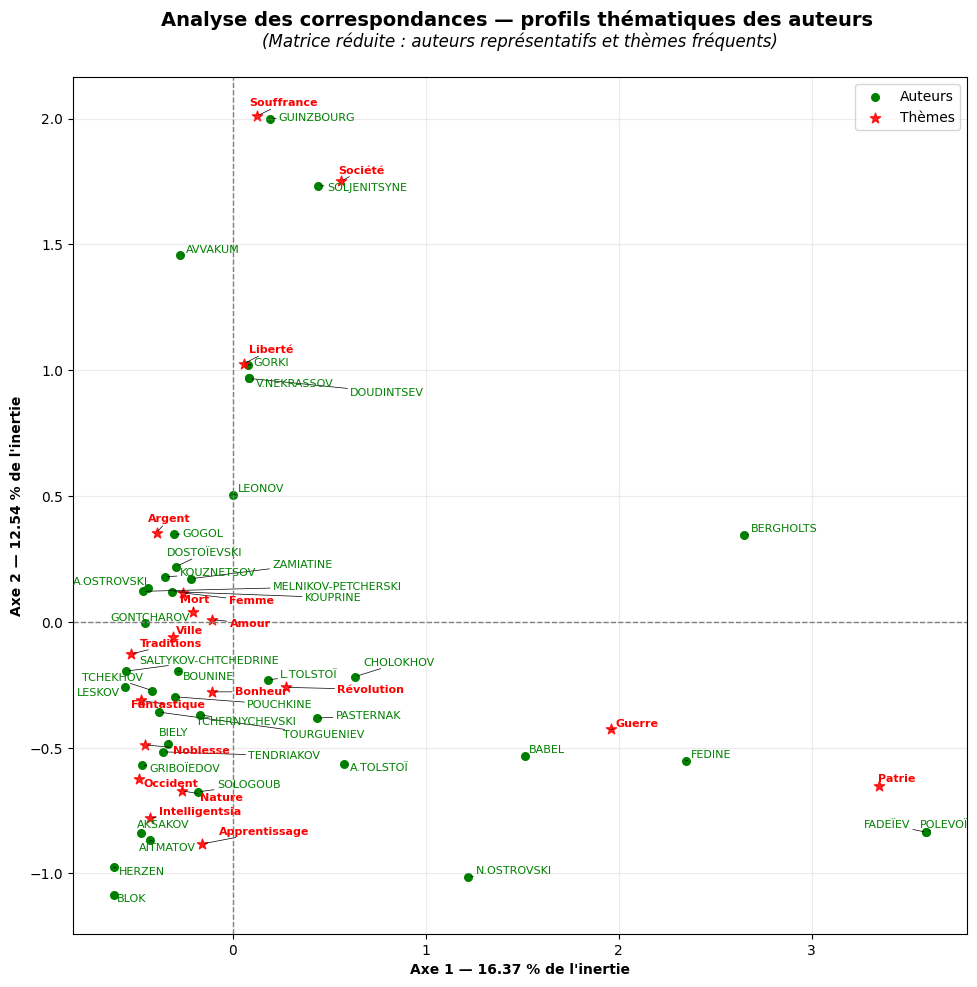

In [8]:
# graphique 
fig, ax = plt.subplots(figsize=(10, 10))

# auteurs
ax.scatter(
    row_coords[0],
    row_coords[1],
    s=30,
    marker="o",
    color="green",
    alpha=1.0,
    label="Auteurs"
)

# thèmes
ax.scatter(
    col_coords[0],
    col_coords[1],
    s=60,
    marker="*",
    color="red",
    alpha=0.85,
    label="Thèmes"
)

# listes destinées à adjust_text
textes_auteurs = []
textes_themes = []


# labels des auteurs
for author in row_coords.index:
    texte = ax.text(
        row_coords.loc[author, 0],
        row_coords.loc[author, 1],
        author,
        color="green",
        fontsize=8,
        alpha=1.0
    )
    textes_auteurs.append(texte)

# labels des thèmes
for theme in col_coords.index:
    texte = ax.text(
        col_coords.loc[theme, 0],
        col_coords.loc[theme, 1],
        theme,
        color="red",
        fontsize=8,
        fontweight="bold"
    )
    textes_themes.append(texte)

# axes zéro
ax.axhline(0, linewidth=1.0, linestyle="--", color="gray")
ax.axvline(0, linewidth=1.0, linestyle="--", color="gray")

# titres et légendes
ax.set_xlabel(f"Axe 1 — {pct[0]:.2f} % de l'inertie", fontweight="bold")
ax.set_ylabel(f"Axe 2 — {pct[1]:.2f} % de l'inertie", fontweight="bold")

ax.legend()
ax.grid(alpha=0.25)

# nécessaire avant adjust_text pour stabiliser la mise en page
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.canvas.draw()

# tous les textes ensemble
textes_tous = textes_auteurs + textes_themes

# coordonnées des points à éviter
x_points = list(row_coords[0]) + list(col_coords[0])
y_points = list(row_coords[1]) + list(col_coords[1])


# ajustement automatique des labels :
# adjust_text doit être appelé après la création de tous les textes 
# et de préférence après fig.tight_layout(),
# sinon il ajuste les positions avant que la figure ait sa taille définitive.
with contextlib.redirect_stdout(io.StringIO()):
    adjust_text(
        textes_tous,
        x=x_points,
        y=y_points,
        ax=ax,
        expand=(1.20, 1.20),
        force_text=(0.25, 0.25),
        force_static=(0.20, 0.20),
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            linewidth=0.5,
            alpha=1.0
        )
    )

titres(fig, ax,
    t1="Analyse des correspondances — profils thématiques des auteurs ", y1=37,
    t2="(Matrice réduite : auteurs représentatifs et thèmes fréquents)", y2=22,
    t3=" ", y3=7
)

fig.savefig(IMG_DIR / "auteurs_thèmes_AC.png", dpi=300)
plt.show()

Dans cette analyse des correspondances, la proximité entre auteurs traduit une similarité de profils thématiques, tandis que la proximité entre thèmes traduit une parenté de distribution entre auteurs. La position relative d’un auteur et d’un thème suggère une association, mais les angles ne doivent pas être interprétés comme des corrélations au sens d’une ACP.

In [9]:
# affichage des pourcentages d’inertie

print("Inertie axe 1 :", round(pct[0], 2), "%")
print("Inertie axe 2 :", round(pct[1], 2), "%")
print("Inertie cumulée axes 1-2 :", round(pct[0] + pct[1], 2), "%")

Inertie axe 1 : 16.37 %
Inertie axe 2 : 12.54 %
Inertie cumulée axes 1-2 : 28.91 %
